# 🦾 Inverse Kinematics Planar Robot 3-DOF
## Pendekatan Machine Learning, Deep Learning, dan Reinforcement Learning

---
> **Prasyarat:** Python, NumPy, dasar ML & Neural Network  
> **Tools:** `numpy`, `matplotlib`, `scikit-learn`, `torch`, `gymnasium`, `stable-baselines3`


---
## 📖 Bagian 1: Pengantar Forward & Inverse Kinematics

### Apa itu Kinematika Robot?

**Forward Kinematics (FK):** Diberikan sudut sendi → hitung posisi end-effector  
- Mudah ✅, solusi **unik**

**Inverse Kinematics (IK):** Diberikan posisi target → hitung sudut sendi  
- Sulit ⚠️, solusi bisa **banyak** atau **tidak ada**

### Robot Planar 3-DOF
- 3 link (lengan): `L1=0.4m`, `L2=0.3m`, `L3=0.2m`
- 3 sendi (joint): `θ1, θ2, θ3` (dalam radian)
- End-effector: ujung lengan ke-3

### Persamaan FK:
```
x = L1·cos(θ1) + L2·cos(θ1+θ2) + L3·cos(θ1+θ2+θ3)
y = L1·sin(θ1) + L2·sin(θ1+θ2) + L3·sin(θ1+θ2+θ3)
```

### 3 Pendekatan IK dengan AI:
| Pendekatan | Metode | Kelebihan |
|------------|--------|-----------|
| **ML** | Supervised (KNN, RF, SVR) | Cepat, mudah dipahami |
| **DL** | Neural Network (PyTorch) | Akurat, generalisasi baik |
| **RL** | Gymnasium + PPO | Adaptif, bisa dapat obstacle |


---
## 🛠️ Bagian 2: Setup & Visualisasi Robot

In [ ]:
# Install dependencies (jalankan sekali)
!pip install gymnasium stable-baselines3 scikit-learn torch matplotlib numpy tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Circle
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

print("✅ Library siap!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 38.5 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0
✅ Library siap!


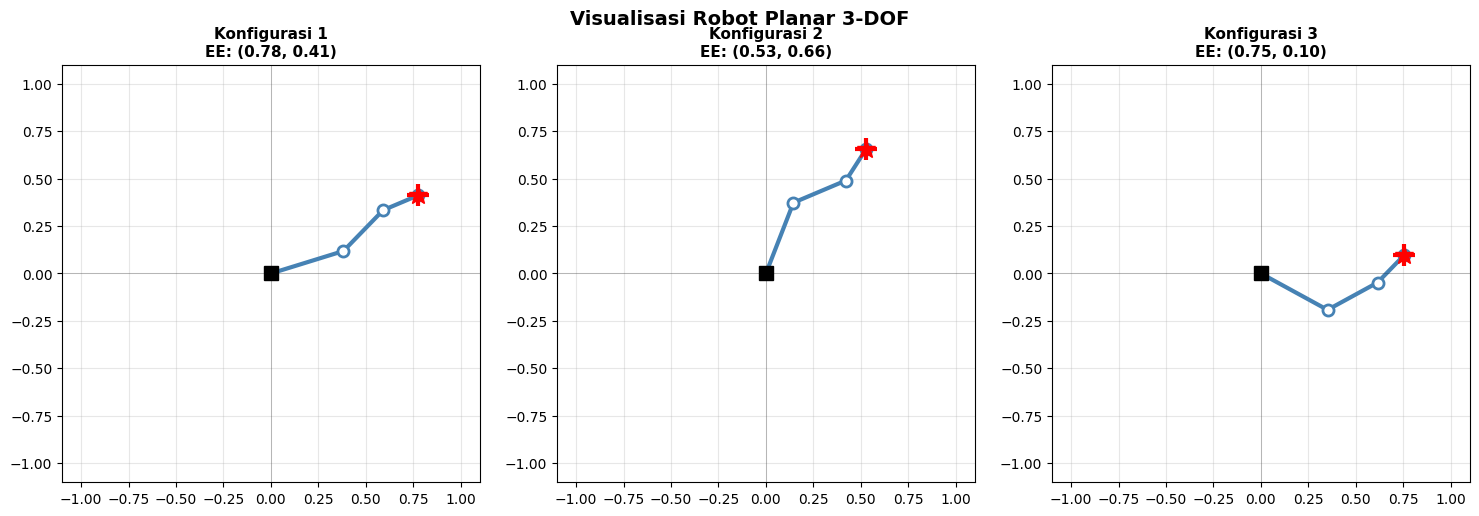

✅ Robot berhasil divisualisasi!


In [ ]:
# ─── Konfigurasi Robot ───────────────────────────────────────────────
L1, L2, L3 = 0.4, 0.3, 0.2       # panjang link (meter)
LINK_LENGTHS = np.array([L1, L2, L3])
JOINT_LIMIT  = np.pi              # ±π radian per sendi
MAX_REACH    = L1 + L2 + L3       # 0.9 m

def forward_kinematics(theta):
    """Hitung posisi setiap sendi dari sudut theta = [θ1, θ2, θ3]."""
    t1, t2, t3 = theta
    # Posisi setiap sendi
    p0 = np.array([0.0, 0.0])
    p1 = p0 + L1 * np.array([np.cos(t1), np.sin(t1)])
    p2 = p1 + L2 * np.array([np.cos(t1+t2), np.sin(t1+t2)])
    p3 = p2 + L3 * np.array([np.cos(t1+t2+t3), np.sin(t1+t2+t3)])
    return p0, p1, p2, p3

def get_end_effector(theta):
    """Langsung return posisi end-effector (p3)."""
    return forward_kinematics(theta)[3]

# ─── Fungsi Plot Robot ────────────────────────────────────────────────
def plot_robot(ax, theta, target=None, title="Robot", color='steelblue'):
    p0, p1, p2, p3 = forward_kinematics(theta)
    points = np.array([p0, p1, p2, p3])
    ax.plot(points[:,0], points[:,1], '-o', color=color,
            linewidth=3, markersize=8, markerfacecolor='white',
            markeredgecolor=color, markeredgewidth=2)
    ax.plot(*p0, 'ks', markersize=10)   # base
    ax.plot(*p3, '*', color='red', markersize=14, label='End-effector')
    if target is not None:
        ax.plot(*target, 'r+', markersize=16, markeredgewidth=3, label='Target')
        ax.add_patch(Circle(target, 0.02, color='red', alpha=0.3))
    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axhline(0, color='k', lw=0.5, alpha=0.3)
    ax.axvline(0, color='k', lw=0.5, alpha=0.3)

# ─── Demo Visualisasi Robot ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
configs = [
    ([0.3, 0.5, -0.4], "Konfigurasi 1"),
    ([1.2, -0.8, 0.6], "Konfigurasi 2"),
    ([-0.5, 1.0, 0.3], "Konfigurasi 3"),
]
for ax, (theta, title) in zip(axes, configs):
    ee = get_end_effector(theta)
    plot_robot(ax, theta, target=ee, title=f"{title}\nEE: ({ee[0]:.2f}, {ee[1]:.2f})")

plt.suptitle("Visualisasi Robot Planar 3-DOF", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Robot berhasil divisualisasi!")


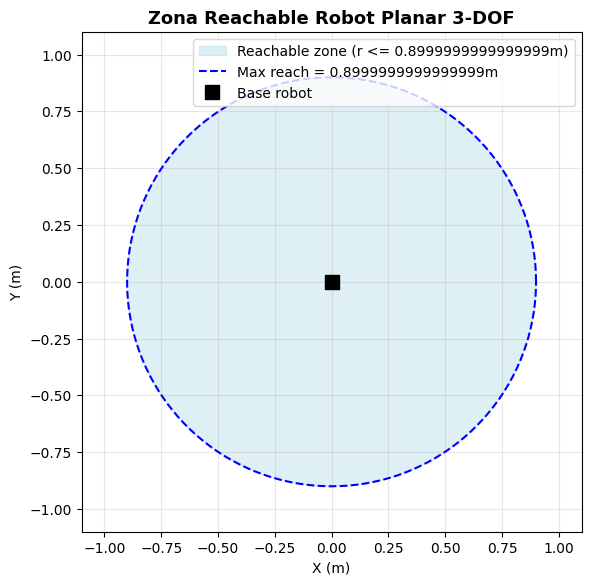

Demo Reachability Check:
  Target               | Jarak    | Reachable?
  ---------------------------------------------
  (0.5, 0.3)             | 0.5831 m | YES
  (0.8, 0.6)             | 1.0000 m | NO
  (1.0, 0.0)             | 1.0000 m | NO
  (1.1, 0.0)             | 1.1000 m | NO
  (0.0, 0.0)             | 0.0000 m | NO


In [ ]:
# ─── Fungsi Reachability Check ───────────────────────────────────────
def is_reachable(target, tol=1e-6):
    """
    Cek apakah posisi target dapat dijangkau robot planar 3-DOF.

    Syarat reachable:
      dist_from_origin <= MAX_REACH (= L1+L2+L3 = 0.9 m)

    Karena joint tidak dibatasi arah, MIN_REACH = 0
    (robot bisa dilipat sehingga semua link saling menghapus).
    """
    target = np.array(target, dtype=float)
    dist = np.linalg.norm(target)
    min_reach = abs(L1 - L2 - L3)   # = 0 untuk konfigurasi ini
    return bool(min_reach - tol <= dist <= MAX_REACH + tol)

def filter_reachable(positions, labels=None):
    """Filter array posisi, kembalikan hanya yang reachable."""
    mask = np.array([is_reachable(p) for p in positions])
    if labels is not None:
        return positions[mask], labels[mask], mask
    return positions[mask], mask

# ─── Visualisasi Zona Reachable ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
theta_range = np.linspace(0, 2*np.pi, 300)
ax.fill(MAX_REACH * np.cos(theta_range),
        MAX_REACH * np.sin(theta_range),
        color='lightblue', alpha=0.4, label=f'Reachable zone (r <= {MAX_REACH}m)')
ax.plot(MAX_REACH * np.cos(theta_range),
        MAX_REACH * np.sin(theta_range),
        'b--', linewidth=1.5, label=f'Max reach = {MAX_REACH}m')
ax.plot(0, 0, 'ks', markersize=10, label='Base robot')
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title("Zona Reachable Robot Planar 3-DOF", fontsize=13, fontweight='bold')
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

# ─── Demo cek reachability ────────────────────────────────────────────
test_points = [(0.5, 0.3), (0.8, 0.6), (1.0, 0.0), (1.1, 0.0), (0.0, 0.0)]
print("Demo Reachability Check:")
print(f"  {'Target':20s} | {'Jarak':8s} | {'Reachable?':10s}")
print("  " + "-"*45)
for pt in test_points:
    d = np.linalg.norm(pt)
    r = is_reachable(pt)
    status = "YES" if r else "NO"
    print(f"  ({pt[0]:.1f}, {pt[1]:.1f}){'':12} | {d:.4f} m | {status}")


---
## 📊 Bagian 3: Membuat Dataset (Sampling FK)

✅ Dataset dibuat: 18000 sampel
   Reachable  : 17446 (96.9%)
   Unreachable: 554 (3.1%)
   ⚠️  554 sampel dibuang (tidak reachable)
   ✅ Dataset bersih: 17446 sampel
   Input  (theta): shape=(17446, 3)     → [θ1, θ2, θ3]
   Output (EE pos): shape=(17446, 2) → [x, y]


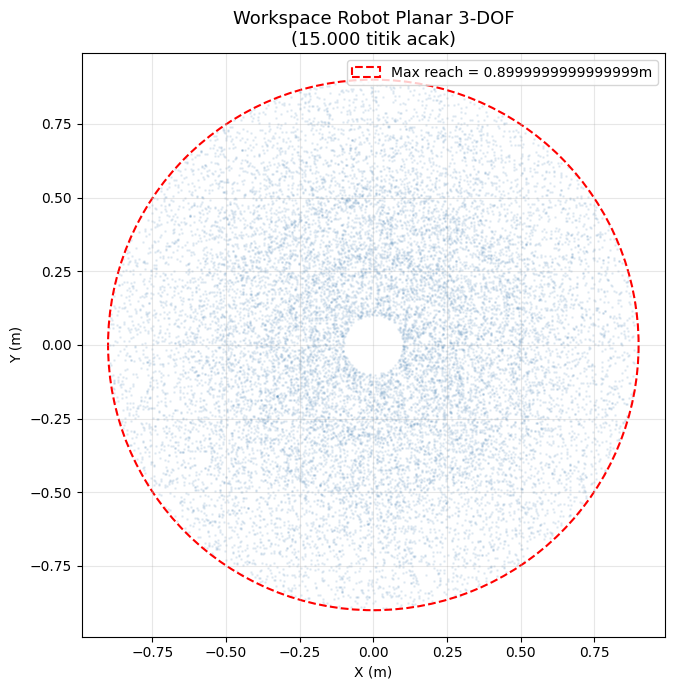

✅ Workspace tervisualisasi!


In [ ]:
# ─── Generate Dataset ────────────────────────────────────────────────
np.random.seed(42)
N = 18000  # jumlah sampel

# Random sudut sendi
thetas = np.random.uniform(-JOINT_LIMIT, JOINT_LIMIT, size=(N, 3)).astype(np.float32)

# Hitung posisi end-effector via FK
ee_positions = np.array([get_end_effector(t) for t in thetas], dtype=np.float32)

# ─── Validasi Reachability Dataset ──────────────────────────────────
_, reach_mask = filter_reachable(ee_positions)
n_reachable = int(reach_mask.sum())
n_unreachable = N - n_reachable
print(f"✅ Dataset dibuat: {N} sampel")
print(f"   Reachable  : {n_reachable} ({n_reachable/N*100:.1f}%)")
print(f"   Unreachable: {n_unreachable} ({n_unreachable/N*100:.1f}%)")
if n_unreachable > 0:
    print(f"   ⚠️  {n_unreachable} sampel dibuang (tidak reachable)")
    ee_positions = ee_positions[reach_mask]
    thetas       = thetas[reach_mask]
    print(f"   ✅ Dataset bersih: {len(ee_positions)} sampel")
else:
    print("   ✅ Semua sampel reachable (expected, karena dari FK sampling)")
print(f"   Input  (theta): shape={thetas.shape}     → [θ1, θ2, θ3]")
print(f"   Output (EE pos): shape={ee_positions.shape} → [x, y]")

# ─── Visualisasi Workspace Robot ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(ee_positions[:,0], ee_positions[:,1],
           alpha=0.1, s=1, color='steelblue')
ax.set_title("Workspace Robot Planar 3-DOF\n(15.000 titik acak)", fontsize=13)
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
circle = plt.Circle((0,0), MAX_REACH, fill=False, color='red',
                     linestyle='--', linewidth=1.5, label=f'Max reach = {MAX_REACH}m')
ax.add_patch(circle)
ax.legend(); plt.tight_layout(); plt.show()
print("✅ Workspace tervisualisasi!")


In [ ]:
# ─── Split Dataset ───────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

# X = posisi target (ee_positions), y = sudut sendi (thetas)
X_train, X_test, y_train, y_test = train_test_split(
    ee_positions, thetas, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} sampel")
print(f"Test : {X_test.shape[0]} sampel")


Train: 13956 sampel
Test : 3490 sampel


---
## 🤖 Bagian 4: Pendekatan 1 — Machine Learning (Supervised)

**Ide:** Buat model regresi dari data (x,y) → (θ1,θ2,θ3)  
Model akan belajar memetakan posisi target ke sudut sendi.


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import time

# ─── Normalisasi ─────────────────────────────────────────────────────
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

ml_results = {}

# ─── 1. KNN ───────────────────────────────────────────────────────────
print("🔵 Training KNN...")
t0 = time.time()
knn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_s, y_train)
knn_pred = knn.predict(X_test_s)
t_knn = time.time() - t0

# Hitung error di end-effector (bukan di sudut)
knn_ee  = np.array([get_end_effector(p) for p in knn_pred])
knn_err = np.linalg.norm(knn_ee - X_test, axis=1)
ml_results['KNN'] = {'pred': knn_pred, 'ee_err': knn_err, 'time': t_knn}
print(f"   ✅ KNN — mean EE error: {knn_err.mean()*100:.2f} cm | time: {t_knn:.1f}s")

# ─── 2. Random Forest ─────────────────────────────────────────────────
print("🌲 Training Random Forest...")
t0 = time.time()
rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
rf.fit(X_train_s, y_train)
rf_pred = rf.predict(X_test_s)
t_rf = time.time() - t0

rf_ee  = np.array([get_end_effector(p) for p in rf_pred])
rf_err = np.linalg.norm(rf_ee - X_test, axis=1)
ml_results['Random Forest'] = {'pred': rf_pred, 'ee_err': rf_err, 'time': t_rf}
print(f"   ✅ RF  — mean EE error: {rf_err.mean()*100:.2f} cm | time: {t_rf:.1f}s")


🔵 Training KNN...
   ✅ KNN — mean EE error: 45.58 cm | time: 0.1s
🌲 Training Random Forest...
   ✅ RF  — mean EE error: 46.03 cm | time: 10.9s


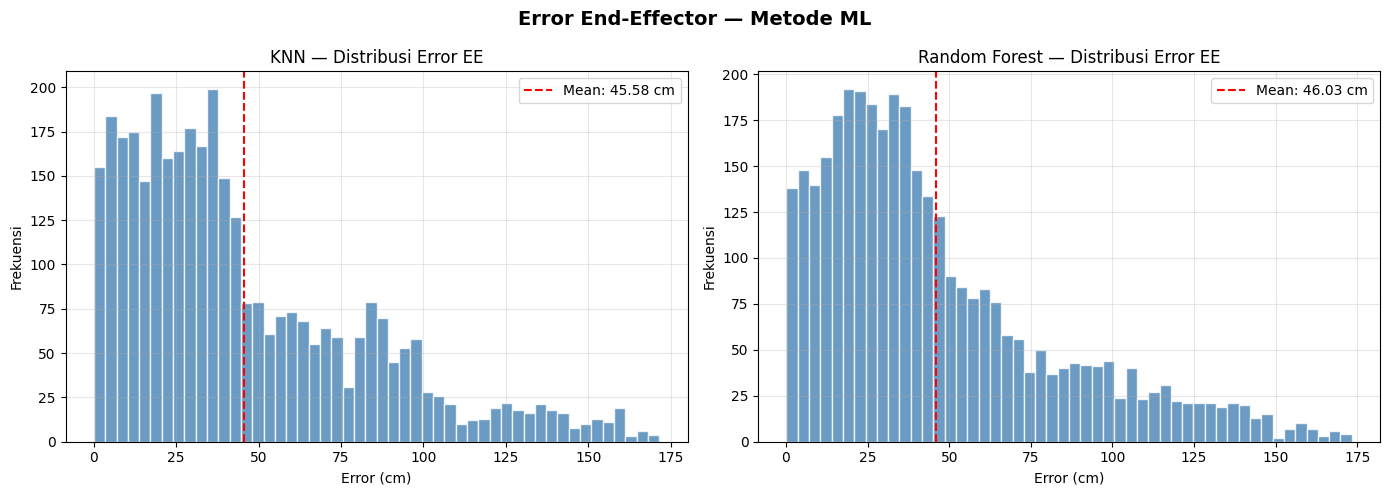

In [ ]:
# ─── Visualisasi Error ML ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, res) in zip(axes, ml_results.items()):
    ax.hist(res['ee_err']*100, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(res['ee_err'].mean()*100, color='red', linestyle='--',
               label=f"Mean: {res['ee_err'].mean()*100:.2f} cm")
    ax.set_title(f"{name} — Distribusi Error EE", fontsize=12)
    ax.set_xlabel("Error (cm)"); ax.set_ylabel("Frekuensi")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Error End-Effector — Metode ML", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


In [ ]:
# ─── Cek Reachability Target Sebelum Prediksi (ML) ──────────────────
print("Cek reachability 5 sampel target test:")
for j, t in enumerate(X_test[:5]):
    r = is_reachable(t)
    d = np.linalg.norm(t)
    status = "YES" if r else "NO"
    print(f"   Target {j+1}: ({t[0]:.3f}, {t[1]:.3f}) | dist={d:.4f}m | Reachable: {status}")

# Filter X_test agar hanya berisi target reachable
X_test_r, y_test_r, mask_r = filter_reachable(X_test, y_test)
print(f"\nX_test reachable: {len(X_test_r)}/{len(X_test)} sampel digunakan untuk evaluasi")


Cek reachability 5 sampel target test:
   Target 1: (-0.522, 0.252) | dist=0.5792m | Reachable: YES
   Target 2: (-0.026, -0.555) | dist=0.5556m | Reachable: YES
   Target 3: (0.102, -0.755) | dist=0.7619m | Reachable: YES
   Target 4: (-0.031, -0.723) | dist=0.7235m | Reachable: YES
   Target 5: (0.221, 0.575) | dist=0.6161m | Reachable: YES

X_test reachable: 3490/3490 sampel digunakan untuk evaluasi


In [ ]:
# ─── ANIMASI ML: Robot bergerak ke 10 target ─────────────────────────
def animate_ik(model_name, predict_fn, n_targets=10, color='steelblue'):
    """Animasi robot bergerak ke target menggunakan hasil prediksi IK."""
    np.random.seed(7)
    sample_idx = np.random.choice(len(X_test), n_targets, replace=False)
    targets = X_test[sample_idx]

    fig, ax = plt.subplots(figsize=(6, 6))

    def update(frame):
        ax.clear()
        target = targets[frame]
        theta_pred = predict_fn(target.reshape(1,-1))[0]
        ee_actual  = get_end_effector(theta_pred)
        err = np.linalg.norm(ee_actual - target) * 100

        plot_robot(ax, theta_pred, target=target,
                   title=f"{model_name}\nTarget ({target[0]:.2f}, {target[1]:.2f}) | Error: {err:.1f} cm",
                   color=color)
        ax.legend(loc='upper right', fontsize=8)

    ani = animation.FuncAnimation(fig, update, frames=n_targets,
                                  interval=800, repeat=True)
    plt.close()
    return ani

# KNN animation
ani_knn = animate_ik("KNN (k=5)",
                     lambda x: knn.predict(scaler_X.transform(x)),
                     color='steelblue')
print("▶️  Animasi KNN:")
HTML(ani_knn.to_jshtml())


▶️  Animasi KNN:


In [ ]:
# Random Forest animation
ani_rf = animate_ik("Random Forest (100 trees)",
                    lambda x: rf.predict(scaler_X.transform(x)),
                    color='forestgreen')
print("▶️  Animasi Random Forest:")
HTML(ani_rf.to_jshtml())


▶️  Animasi Random Forest:


---
## 🧠 Bagian 5: Pendekatan 2 — Deep Learning (PyTorch MLP)

**Ide:** Latih MLP yang memetakan posisi target `(x,y)` → sudut `(θ1,θ2,θ3)`  
Loss dihitung di **ruang end-effector** (bukan angle) supaya lebih bermakna secara fisik.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")

# ─── MLP Architecture ─────────────────────────────────────────────────
class IKNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 3),
        )
        # Output: sudut dalam [-π, π]
    def forward(self, x):
        out = self.net(x)
        return torch.tanh(out) * torch.pi  # clamp ke [-π, π]

model_dl = IKNet().to(device)
print(f"✅ Model: {sum(p.numel() for p in model_dl.parameters()):,} parameter")


🖥️  Device: cuda
✅ Model: 530,179 parameter


In [ ]:
# ─── FK differentiable (PyTorch) ─────────────────────────────────────
def fk_torch(theta):
    """Differentiable FK untuk loss di ruang kartesian."""
    t1, t2, t3 = theta[:,0], theta[:,1], theta[:,2]
    x = (L1*torch.cos(t1)
       + L2*torch.cos(t1+t2)
       + L3*torch.cos(t1+t2+t3))
    y = (L1*torch.sin(t1)
       + L2*torch.sin(t1+t2)
       + L3*torch.sin(t1+t2+t3))
    return torch.stack([x, y], dim=1)

# ─── Dataset & DataLoader ─────────────────────────────────────────────
X_tr_t = torch.FloatTensor(X_train).to(device)
X_te_t = torch.FloatTensor(X_test).to(device)
y_tr_t = torch.FloatTensor(y_train).to(device)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_dl = DataLoader(train_ds, batch_size=512, shuffle=True)

# ─── Training Loop ────────────────────────────────────────────────────
optimizer = optim.Adam(model_dl.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
EPOCHS = 100

train_losses, val_losses = [], []
print("🚀 Training DL model...")

for epoch in range(EPOCHS):
    model_dl.train()
    ep_loss = 0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        pred_theta = model_dl(xb)
        pred_ee    = fk_torch(pred_theta)
        loss = nn.MSELoss()(pred_ee, xb)  # loss di ruang EE
        loss.backward()
        optimizer.step()
        ep_loss += loss.item()
    train_losses.append(ep_loss / len(train_dl))

    model_dl.eval()
    with torch.no_grad():
        val_pred_theta = model_dl(X_te_t)
        val_pred_ee    = fk_torch(val_pred_theta)
        val_loss = nn.MSELoss()(val_pred_ee, X_te_t).item()
    val_losses.append(val_loss)
    scheduler.step()

    if (epoch+1) % 20 == 0:
        print(f"   Epoch {epoch+1:3d}/{EPOCHS} | Train: {train_losses[-1]:.6f} | Val: {val_loss:.6f}")

print("✅ Training selesai!")


🚀 Training DL model...
   Epoch  20/100 | Train: 0.004879 | Val: 0.003918
   Epoch  40/100 | Train: 0.003098 | Val: 0.001832
   Epoch  60/100 | Train: 0.002746 | Val: 0.001282
   Epoch  80/100 | Train: 0.002406 | Val: 0.001070
   Epoch 100/100 | Train: 0.002123 | Val: 0.001260
✅ Training selesai!


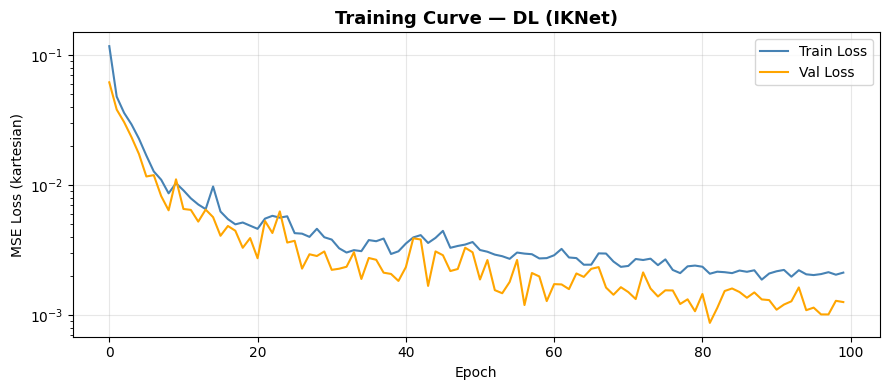

✅ DL — mean EE error: 2.15 cm


In [ ]:
# ─── Training Curve ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label='Train Loss', color='steelblue')
ax.plot(val_losses,   label='Val Loss',   color='orange')
ax.set_title("Training Curve — DL (IKNet)", fontsize=13, fontweight='bold')
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss (kartesian)")
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout(); plt.show()

# Hitung error DL
model_dl.eval()
with torch.no_grad():
    dl_pred = model_dl(X_te_t).cpu().numpy()

dl_ee  = np.array([get_end_effector(p) for p in dl_pred])
dl_err = np.linalg.norm(dl_ee - X_test, axis=1)
print(f"✅ DL — mean EE error: {dl_err.mean()*100:.2f} cm")


In [ ]:
# ─── Cek Reachability Target Sebelum Prediksi (DL) ──────────────────
print("Validasi reachability untuk evaluasi DL...")
# Gunakan X_test_r (sudah difilter) untuk konsistensi
print(f"   Evaluasi menggunakan {len(X_test_r)} target reachable")
import torch as _torch
X_te_r_t = _torch.FloatTensor(X_test_r).to(device)


Validasi reachability untuk evaluasi DL...
   Evaluasi menggunakan 3490 target reachable


In [ ]:
# ─── ANIMASI DL: Robot bergerak ke target ─────────────────────────────
def dl_predict(xy):
    model_dl.eval()
    with torch.no_grad():
        t = torch.FloatTensor(xy).to(device)
        return model_dl(t).cpu().numpy()

ani_dl = animate_ik("Deep Learning (MLP PyTorch)",
                    dl_predict, color='darkorange')
print("▶️  Animasi Deep Learning:")
HTML(ani_dl.to_jshtml())


▶️  Animasi Deep Learning:


---
## 🕹️ Bagian 6: Pendekatan 3 — Reinforcement Learning (Gymnasium + PPO)

**Ide:** Agent belajar sendiri menggerakkan sendi robot untuk menjangkau target.  
Tidak butuh dataset — agent belajar dari **reward** berdasarkan seberapa dekat end-effector ke target.

**Reward:** `-distance(EE, target)` + bonus `+10` kalau berhasil (<2 cm)


In [ ]:
import gymnasium as gym
from gymnasium import spaces

# ─── Joint Limits Realistis ───────────────────────────────────────────
# θ1: bebas berputar (shoulder)
# θ2: elbow, hindari lipatan ekstrem
# θ3: wrist, range lebih sempit
JOINT_LIMITS_LOW  = np.array([-np.pi,      -2*np.pi/3, -np.pi/2], dtype=np.float32)
JOINT_LIMITS_HIGH = np.array([ np.pi,       2*np.pi/3,  np.pi/2], dtype=np.float32)

class PlanarRobot3DOFEnv(gym.Env):
    """Custom Gymnasium environment untuk robot planar 3-DOF."""
    metadata = {"render_modes": ["rgb_array"], "render_fps": 30}

    def __init__(self, render_mode=None):
        super().__init__()
        self.render_mode = render_mode
        self.max_steps   = 200
        self.goal_thresh = 0.02  # 2 cm

        # Observation: [θ1,θ2,θ3, dθ1,dθ2,dθ3, x_target, y_target]
        obs_high = np.concatenate([
            JOINT_LIMITS_HIGH,
            np.array([5.0, 5.0, 5.0], dtype=np.float32),
            np.array([MAX_REACH, MAX_REACH], dtype=np.float32)
        ])
        self.observation_space = spaces.Box(-obs_high, obs_high, dtype=np.float32)

        # Action: delta sudut per sendi (lebih ketat untuk θ2 & θ3)
        act_high = np.array([0.15, 0.10, 0.08], dtype=np.float32)
        self.action_space = spaces.Box(-act_high, act_high, dtype=np.float32)
        self._reset_state()

    def _reset_state(self):
        # Inisialisasi di tengah joint range (bukan zero) untuk variasi
        self.theta  = np.random.uniform(
            JOINT_LIMITS_LOW * 0.3, JOINT_LIMITS_HIGH * 0.3
        ).astype(np.float32)
        self.dtheta = np.zeros(3, dtype=np.float32)
        self.steps  = 0
        # Generate target reachable via FK sampling
        while True:
          target_angles = np.random.uniform(-np.pi, np.pi, 3).astype(np.float32)
          self.target   = get_end_effector(target_angles).astype(np.float32)
          if is_reachable(self.target):
            break
        # # Safety check reachability
        # assert is_reachable(self.target), \
        #     f"Target {self.target} TIDAK reachable! dist={np.linalg.norm(self.target):.4f} > MAX_REACH={MAX_REACH}"

    def _get_obs(self):
        return np.concatenate([self.theta, self.dtheta, self.target]).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            np.random.seed(seed)
        self._reset_state()
        return self._get_obs(), {}

    def step(self, action):
        # Clip action per joint sesuai batas masing-masing
        act_high = np.array([0.15, 0.10, 0.08], dtype=np.float32)
        delta = np.clip(action, -act_high, act_high).astype(np.float32)

        # Update theta dengan joint limits realistis
        self.theta  = np.clip(self.theta + delta,
                              JOINT_LIMITS_LOW, JOINT_LIMITS_HIGH).astype(np.float32)
        self.dtheta = delta

        ee   = get_end_effector(self.theta)
        dist = float(np.linalg.norm(ee - self.target))

        # ── Reward shaping ─────────────────────────────────────────────
        # 1. Proximity reward
        reward = -dist

        # 2. Penalti konfigurasi degenerate:
        #    - Hindari θ2, θ3 yang terlalu besar (lipatan ekstrem)
        angle_penalty = 0.005 * float(np.sum(self.theta[1:]**2))
        reward -= angle_penalty

        # 3. Bonus sukses
        terminated = False
        if dist < self.goal_thresh:
            reward += 10.0
            terminated = True

        self.steps += 1
        truncated = self.steps >= self.max_steps
        return self._get_obs(), reward, terminated, truncated, {"dist": dist}

    def render(self):
        fig, ax = plt.subplots(figsize=(5, 5))
        plot_robot(ax, self.theta, target=self.target,
                   title="RL Agent", color='purple')
        fig.canvas.draw()
        img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        img = img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        plt.close(fig)
        return img

print("Joint limits:")
print(f"  theta1 (shoulder): [{np.degrees(JOINT_LIMITS_LOW[0]):.0f}, {np.degrees(JOINT_LIMITS_HIGH[0]):.0f}] deg")
print(f"  theta2 (elbow)   : [{np.degrees(JOINT_LIMITS_LOW[1]):.0f}, {np.degrees(JOINT_LIMITS_HIGH[1]):.0f}] deg")
print(f"  theta3 (wrist)   : [{np.degrees(JOINT_LIMITS_LOW[2]):.0f}, {np.degrees(JOINT_LIMITS_HIGH[2]):.0f}] deg")
print("Environment terdefinisi!")
from gymnasium.utils.env_checker import check_env
env_test = PlanarRobot3DOFEnv()
check_env(env_test, warn=True)
print("check_env passed!")


Joint limits:
  theta1 (shoulder): [-180, 180] deg
  theta2 (elbow)   : [-120, 120] deg
  theta3 (wrist)   : [-90, 90] deg
Environment terdefinisi!
check_env passed!


In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import EvalCallback, BaseCallback
import os

class RewardLoggerCallback(BaseCallback):
    """
    Callback untuk mencatat mean reward dan mean episode length
    setiap `log_freq` timestep — digunakan untuk plot learning curve.
    """
    def __init__(self, log_freq=5000, verbose=0):
        super().__init__(verbose)
        self.log_freq       = log_freq
        self.timesteps_log  = []
        self.mean_rewards   = []
        self.mean_ep_lens   = []
        self._ep_rewards    = []
        self._ep_lens       = []
        self._cur_ep_reward = None
        self._cur_ep_len    = None

    def _on_training_start(self):
        self._cur_ep_reward = np.zeros(self.training_env.num_envs)
        self._cur_ep_len    = np.zeros(self.training_env.num_envs, dtype=int)

    def _on_step(self):
        rewards = self.locals["rewards"]
        dones   = self.locals["dones"]
        self._cur_ep_reward += rewards
        self._cur_ep_len    += 1

        for idx, done in enumerate(dones):
            if done:
                self._ep_rewards.append(self._cur_ep_reward[idx])
                self._ep_lens.append(self._cur_ep_len[idx])
                self._cur_ep_reward[idx] = 0
                self._cur_ep_len[idx]    = 0

        if self.n_calls % self.log_freq == 0 and len(self._ep_rewards) > 0:
            mean_r   = float(np.mean(self._ep_rewards[-50:]))
            mean_len = float(np.mean(self._ep_lens[-50:]))
            self.timesteps_log.append(self.num_timesteps)
            self.mean_rewards.append(mean_r)
            self.mean_ep_lens.append(mean_len)
            print(f"   ⏱  {self.num_timesteps:>8,} steps | "
                  f"mean_reward: {mean_r:7.3f} | mean_ep_len: {mean_len:.1f}")
        return True

# ─── Training PPO ─────────────────────────────────────────────────────
vec_env  = make_vec_env(PlanarRobot3DOFEnv, n_envs=16)
eval_env = make_vec_env(PlanarRobot3DOFEnv, n_envs=1)

model_rl = PPO(
    "MlpPolicy", vec_env,
    learning_rate=3e-4,
    n_steps=1024, batch_size=256, n_epochs=10,
    gamma=0.99, gae_lambda=0.95,
    clip_range=0.2, ent_coef=0.01,
    policy_kwargs=dict(net_arch=dict(pi=[256,256], vf=[256,256])),
    verbose=0
)

eval_cb = EvalCallback(eval_env, eval_freq=20000, n_eval_episodes=10,
                       best_model_save_path="./rl_best/", verbose=0)

reward_logger = RewardLoggerCallback(log_freq=5000)
print("🚀 Training PPO (800k timesteps)...")
model_rl.learn(total_timesteps=800_000,
               callback=[eval_cb, reward_logger])
print("✅ Training RL selesai!")


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


🚀 Training PPO (800k timesteps)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


   ⏱    80,000 steps | mean_reward: -145.031 | mean_ep_len: 195.5
   ⏱   160,000 steps | mean_reward: -94.802 | mean_ep_len: 188.2
   ⏱   240,000 steps | mean_reward: -73.812 | mean_ep_len: 174.5
   ⏱   320,000 steps | mean_reward: -62.756 | mean_ep_len: 171.8
   ⏱   400,000 steps | mean_reward: -44.798 | mean_ep_len: 158.6
   ⏱   480,000 steps | mean_reward: -34.900 | mean_ep_len: 137.6
   ⏱   560,000 steps | mean_reward: -21.025 | mean_ep_len: 107.7
   ⏱   640,000 steps | mean_reward: -21.756 | mean_ep_len: 113.2
   ⏱   720,000 steps | mean_reward: -15.871 | mean_ep_len: 89.6
   ⏱   800,000 steps | mean_reward: -14.906 | mean_ep_len: 85.1
✅ Training RL selesai!


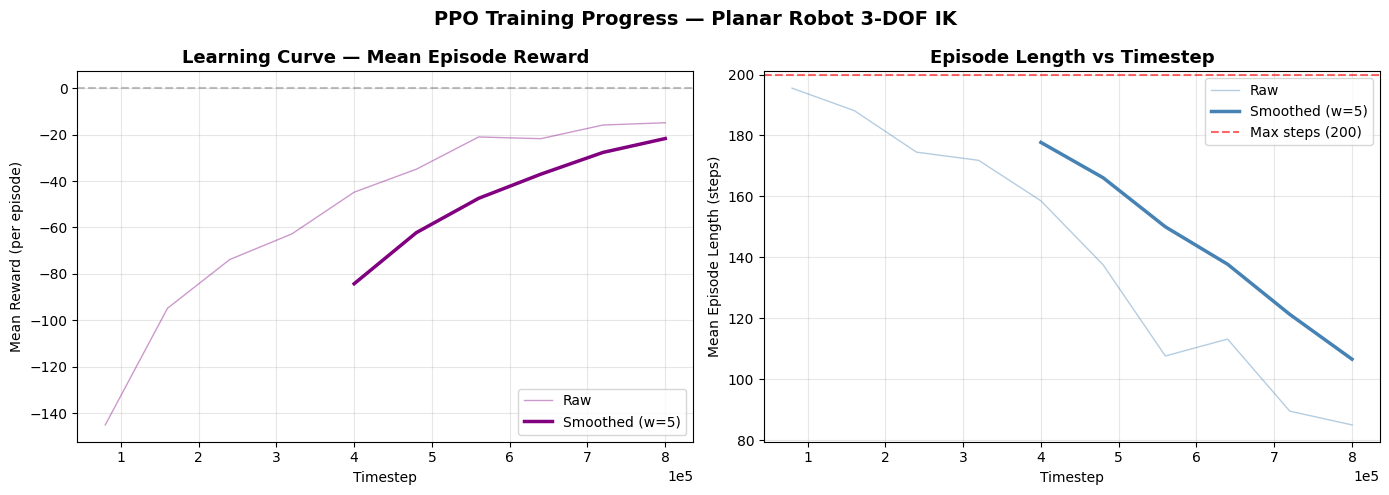

Reward awal  (avg 10 pertama): -52.966
Reward akhir (avg 10 terakhir): -52.966
Peningkatan  : +0.000


In [ ]:
# ─── Visualisasi Learning Curve (Reward vs Timestep) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Mean Episode Reward ───────────────────────────────────────
ax = axes[0]
ts  = np.array(reward_logger.timesteps_log)
rew = np.array(reward_logger.mean_rewards)

ax.plot(ts, rew, color='purple', alpha=0.4, linewidth=1, label='Raw')

# Smoothing dengan rolling average
if len(rew) >= 10:
    window = max(5, len(rew) // 10)
    smooth = np.convolve(rew, np.ones(window)/window, mode='valid')
    ts_smooth = ts[window-1:]
    ax.plot(ts_smooth, smooth, color='purple', linewidth=2.5, label=f'Smoothed (w={window})')

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title("Learning Curve — Mean Episode Reward", fontsize=13, fontweight='bold')
ax.set_xlabel("Timestep"); ax.set_ylabel("Mean Reward (per episode)")
ax.legend(); ax.grid(True, alpha=0.3)
ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

# ── Plot 2: Mean Episode Length ───────────────────────────────────────
ax2 = axes[1]
ep_len = np.array(reward_logger.mean_ep_lens)

ax2.plot(ts, ep_len, color='steelblue', alpha=0.4, linewidth=1, label='Raw')

if len(ep_len) >= 10:
    smooth_len = np.convolve(ep_len, np.ones(window)/window, mode='valid')
    ax2.plot(ts_smooth, smooth_len, color='steelblue', linewidth=2.5,
             label=f'Smoothed (w={window})')

ax2.axhline(200, color='red', linestyle='--', alpha=0.6, label='Max steps (200)')
ax2.set_title("Episode Length vs Timestep", fontsize=13, fontweight='bold')
ax2.set_xlabel("Timestep"); ax2.set_ylabel("Mean Episode Length (steps)")
ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

plt.suptitle("PPO Training Progress — Planar Robot 3-DOF IK",
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Ringkasan learning ────────────────────────────────────────────────
if len(rew) > 0:
    print(f"Reward awal  (avg 10 pertama): {np.mean(rew[:10]):.3f}")
    print(f"Reward akhir (avg 10 terakhir): {np.mean(rew[-10:]):.3f}")
    improvement = np.mean(rew[-10:]) - np.mean(rew[:10])
    print(f"Peningkatan  : {improvement:+.3f}")


In [ ]:
# ─── Evaluasi RL ──────────────────────────────────────────────────────
eval_single = PlanarRobot3DOFEnv()
successes, distances = [], []

model_rl.load('./rl_best/best_model.zip')
np.random.seed(99)
for _ in range(200):
    obs, _ = eval_single.reset()
    for _ in range(200):
        action, _ = model_rl.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_single.step(action)
        if terminated or truncated:
            break
    distances.append(info['dist'])
    successes.append(info['dist'] < 0.02)

print(f"✅ RL Success rate : {np.mean(successes)*100:.1f}%")
print(f"✅ RL Mean EE error: {np.mean(distances)*100:.2f} cm")
rl_errors = np.array(distances)


✅ RL Success rate : 50.0%
✅ RL Mean EE error: 6.57 cm


In [ ]:
# ─── ANIMASI RL: Agent mencapai target step-by-step ──────────────────
def animate_rl(n_episodes=8):
    """Animasi episode RL: pergerakan robot frame per frame."""
    # Kumpulkan trajectory dari beberapa episode
    trajectories = []
    env_anim = PlanarRobot3DOFEnv()
    np.random.seed(55)
    for ep in range(n_episodes):
        obs, _ = env_anim.reset(seed=ep*10)
        target = env_anim.target.copy()
        traj = []
        for _ in range(80):
            action, _ = model_rl.predict(obs, deterministic=True)
            obs, _, terminated, truncated, info = env_anim.step(action)
            traj.append((env_anim.theta.copy(), target.copy(), info['dist']))
            if terminated or truncated:
                break
        trajectories.append(traj)

    # Flatten: semua episode diputar berurutan
    all_frames = []
    for traj in trajectories:
        # Ambil setiap 3 frame supaya animasi tidak terlalu lambat
        all_frames.extend(traj[::3])
        # Tahan frame terakhir 5x
        all_frames.extend([traj[-1]] * 5)

    fig, ax = plt.subplots(figsize=(6, 6))

    def update(i):
        ax.clear()
        theta, target, dist = all_frames[i]
        ee = get_end_effector(theta)
        success = dist < 0.02
        color = 'green' if success else 'purple'
        status = "✅ BERHASIL!" if success else f"dist: {dist*100:.1f} cm"
        plot_robot(ax, theta, target=target,
                   title=f"RL Agent (PPO)\n{status}", color=color)
        ax.legend(loc='upper right', fontsize=8)

    ani = animation.FuncAnimation(fig, update, frames=len(all_frames),
                                  interval=120, repeat=True)
    plt.close()
    return ani

ani_rl = animate_rl()
print("▶️  Animasi Reinforcement Learning:")
HTML(ani_rl.to_jshtml())


---
## 📊 Bagian 7: Perbandingan Ketiga Metode

In [ ]:
# ─── Demo: Cek Target Manual Sebelum IK ─────────────────────────────
def predict_ik_safe(target_xy, method='dl'):
    """
    Prediksi IK dengan validasi reachability terlebih dahulu.
    method: 'knn', 'rf', 'dl'
    """
    target = np.array(target_xy, dtype=np.float32)
    dist   = np.linalg.norm(target)

    if not is_reachable(target):
        print(f"TIDAK REACHABLE: ({target[0]:.3f}, {target[1]:.3f})")
        print(f"   Jarak dari origin: {dist:.4f} m > MAX_REACH: {MAX_REACH} m")
        return None

    print(f"REACHABLE: ({target[0]:.3f}, {target[1]:.3f}) | dist={dist:.4f} m")

    if method == 'knn':
        pred = knn.predict(scaler_X.transform(target.reshape(1,-1)))[0]
    elif method == 'rf':
        pred = rf.predict(scaler_X.transform(target.reshape(1,-1)))[0]
    else:  # dl (default)
        import torch
        model_dl.eval()
        with torch.no_grad():
            t = torch.FloatTensor(target.reshape(1,-1)).to(device)
            pred = model_dl(t).cpu().numpy()[0]

    ee  = get_end_effector(pred)
    err = np.linalg.norm(ee - target) * 100
    print(f"   Prediksi theta : [{pred[0]:.3f}, {pred[1]:.3f}, {pred[2]:.3f}] rad")
    print(f"   EE aktual      : ({ee[0]:.3f}, {ee[1]:.3f}) m")
    print(f"   Error EE       : {err:.2f} cm")
    return pred

# ─── Uji dengan berbagai target ──────────────────────────────────────
print("=" * 55)
print("Target REACHABLE:")
predict_ik_safe((0.5, 0.3),   method='dl')
print()
predict_ik_safe((0.7, -0.4),  method='dl')

print()
print("=" * 55)
print("Target TIDAK REACHABLE:")
predict_ik_safe((1.0, 0.5),   method='dl')   # dist ~1.12 > 0.9
predict_ik_safe((-0.8, 0.7),  method='dl')   # dist ~1.06 > 0.9


Target REACHABLE:
REACHABLE: (0.500, 0.300) | dist=0.5831 m
   Prediksi theta : [-0.223, 2.020, -1.265] rad
   EE aktual      : (0.495, 0.305) m
   Error EE       : 0.70 cm

REACHABLE: (0.700, -0.400) | dist=0.8062 m
   Prediksi theta : [-0.827, 0.972, -0.941] rad
   EE aktual      : (0.707, -0.394) m
   Error EE       : 0.94 cm

Target TIDAK REACHABLE:
TIDAK REACHABLE: (1.000, 0.500)
   Jarak dari origin: 1.1180 m > MAX_REACH: 0.8999999999999999 m
TIDAK REACHABLE: (-0.800, 0.700)
   Jarak dari origin: 1.0630 m > MAX_REACH: 0.8999999999999999 m


In [ ]:
# ─── Tabel Ringkasan ──────────────────────────────────────────────────
import pandas as pd

summary = {
    'Metode':       ['KNN', 'Random Forest', 'Deep Learning (MLP)', 'RL (PPO)'],
    'Mean Error (cm)': [
        round(ml_results['KNN']['ee_err'].mean()*100, 2),
        round(ml_results['Random Forest']['ee_err'].mean()*100, 2),
        round(dl_err.mean()*100, 2),
        round(rl_errors.mean()*100, 2),
    ],
    'Butuh Dataset': ['✅ Ya','✅ Ya','✅ Ya','❌ Tidak'],
    'Training Time': [
        f"{ml_results['KNN']['time']:.1f}s",
        f"{ml_results['Random Forest']['time']:.1f}s",
        f"~{EPOCHS} epoch",
        '200k steps',
    ],
    'Kelebihan': [
        'Simpel, cepat',
        'Robust, stabil',
        'Akurat, generalisasi',
        'Adaptif, no dataset',
    ]
}
df = pd.DataFrame(summary)
print(df.to_string(index=False))


             Metode  Mean Error (cm) Butuh Dataset Training Time            Kelebihan
                KNN            45.58          ✅ Ya          0.1s        Simpel, cepat
      Random Forest            46.03          ✅ Ya         10.9s       Robust, stabil
Deep Learning (MLP)             2.15          ✅ Ya    ~100 epoch Akurat, generalisasi
           RL (PPO)             6.57       ❌ Tidak    200k steps  Adaptif, no dataset


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


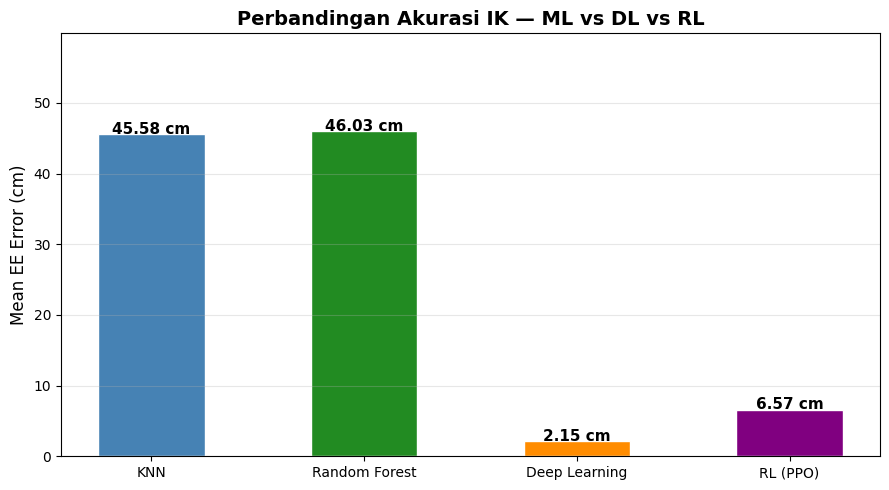

In [ ]:
# ─── Bar Chart Perbandingan Error ────────────────────────────────────
labels  = ['KNN', 'Random Forest', 'Deep Learning', 'RL (PPO)']
errors  = [
    ml_results['KNN']['ee_err'].mean()*100,
    ml_results['Random Forest']['ee_err'].mean()*100,
    dl_err.mean()*100,
    rl_errors.mean()*100,
]
colors  = ['steelblue', 'forestgreen', 'darkorange', 'purple']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, errors, color=colors, edgecolor='white', width=0.5)
for bar, err in zip(bars, errors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{err:.2f} cm', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel("Mean EE Error (cm)", fontsize=12)
ax.set_title("Perbandingan Akurasi IK — ML vs DL vs RL", fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, max(errors)*1.3)
plt.tight_layout(); plt.show()


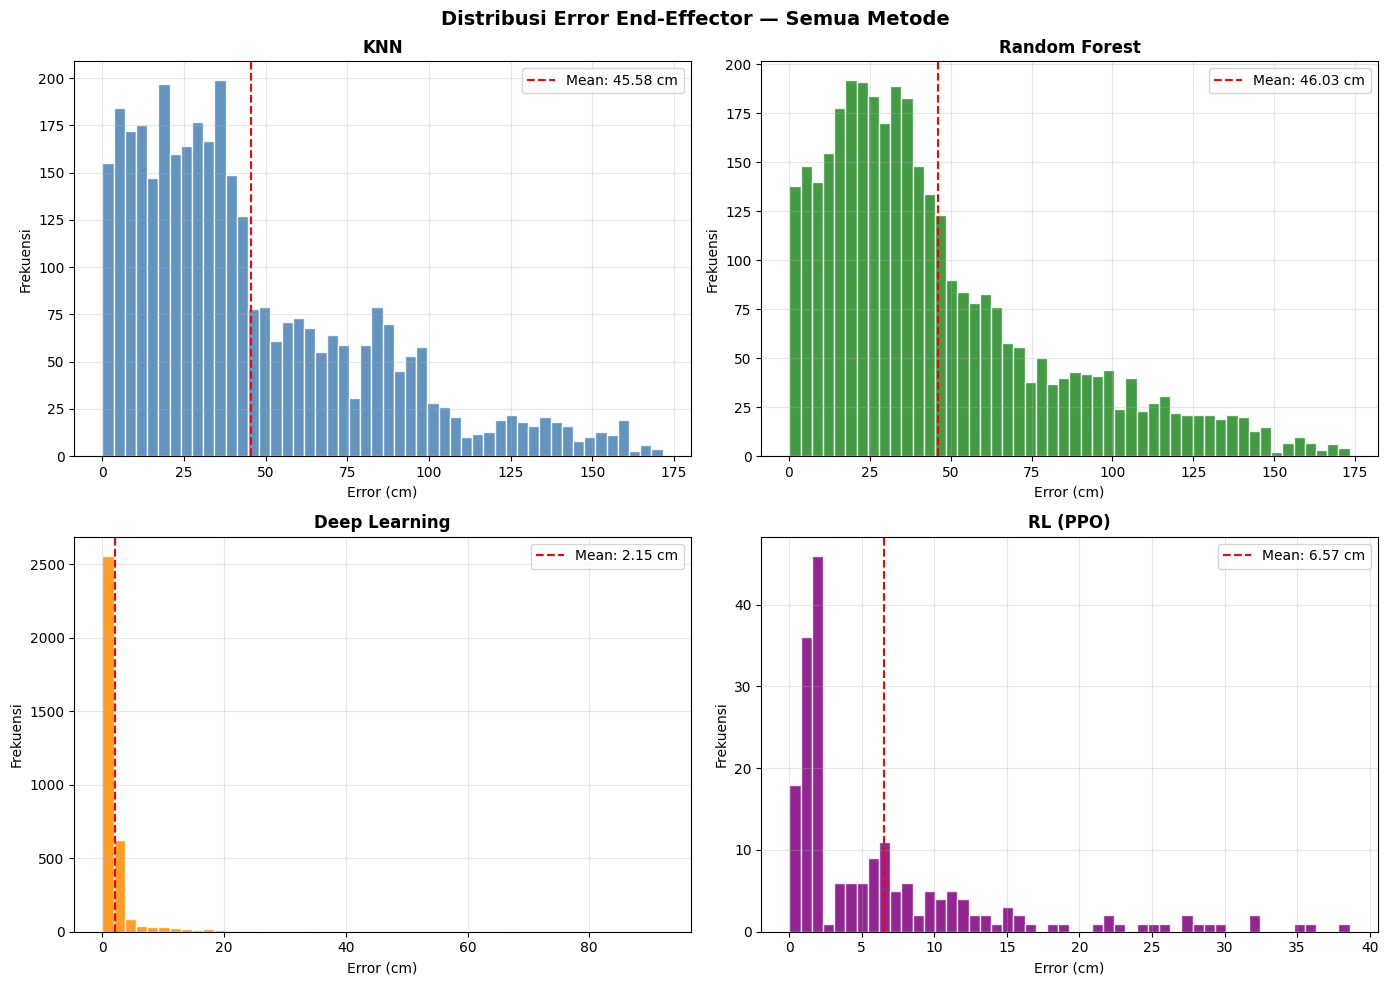

In [ ]:
# ─── Distribusi Error Semua Metode ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

all_errs = [
    ('KNN',           ml_results['KNN']['ee_err']*100,           'steelblue'),
    ('Random Forest', ml_results['Random Forest']['ee_err']*100, 'forestgreen'),
    ('Deep Learning', dl_err*100,                                'darkorange'),
    ('RL (PPO)',       rl_errors*100,                             'purple'),
]
for ax, (name, errs, c) in zip(axes, all_errs):
    ax.hist(errs, bins=50, color=c, edgecolor='white', alpha=0.85)
    ax.axvline(errs.mean(), color='red', linestyle='--',
               label=f"Mean: {errs.mean():.2f} cm")
    ax.set_title(f"{name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Error (cm)"); ax.set_ylabel("Frekuensi")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Distribusi Error End-Effector — Semua Metode",
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 📝 Kesimpulan & Diskusi

### Kapan Menggunakan Metode Apa?

| Kondisi | Rekomendasi |
|---------|-------------|
| Dataset besar tersedia, butuh hasil cepat | **Random Forest / KNN** |
| Butuh akurasi tinggi, punya GPU | **Deep Learning (MLP)** |
| Tidak ada dataset, lingkungan dinamis | **Reinforcement Learning** |
| Real-time control sederhana | **KNN** |
| Robot dengan obstacle/constraints | **RL** |

### Pertanyaan Diskusi
1. Mengapa DL lebih akurat dari KNN meskipun datanya sama?
2. Mengapa RL tidak butuh dataset tetapi training-nya lebih lama?
3. Bagaimana menambahkan **obstacle avoidance** pada pendekatan RL?
4. Apa kelemahan supervised learning (ML/DL) untuk IK pada konfigurasi baru?

### Tugas Praktikum
- Ubah panjang link menjadi `[0.5, 0.4, 0.3]` dan bandingkan hasilnya
- Optimasi metode machine learning dengan menggunakan metode yang ada atau yang lain

---
*Selamat belajar! 🦾🤖*
